In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
def load_exam(data_path=r"C:\Users\nooth\Downloads"):
    csv_path = os.path.join(data_path,"diabetes")
    return pd.read_csv(csv_path)

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479  

<Axes: >

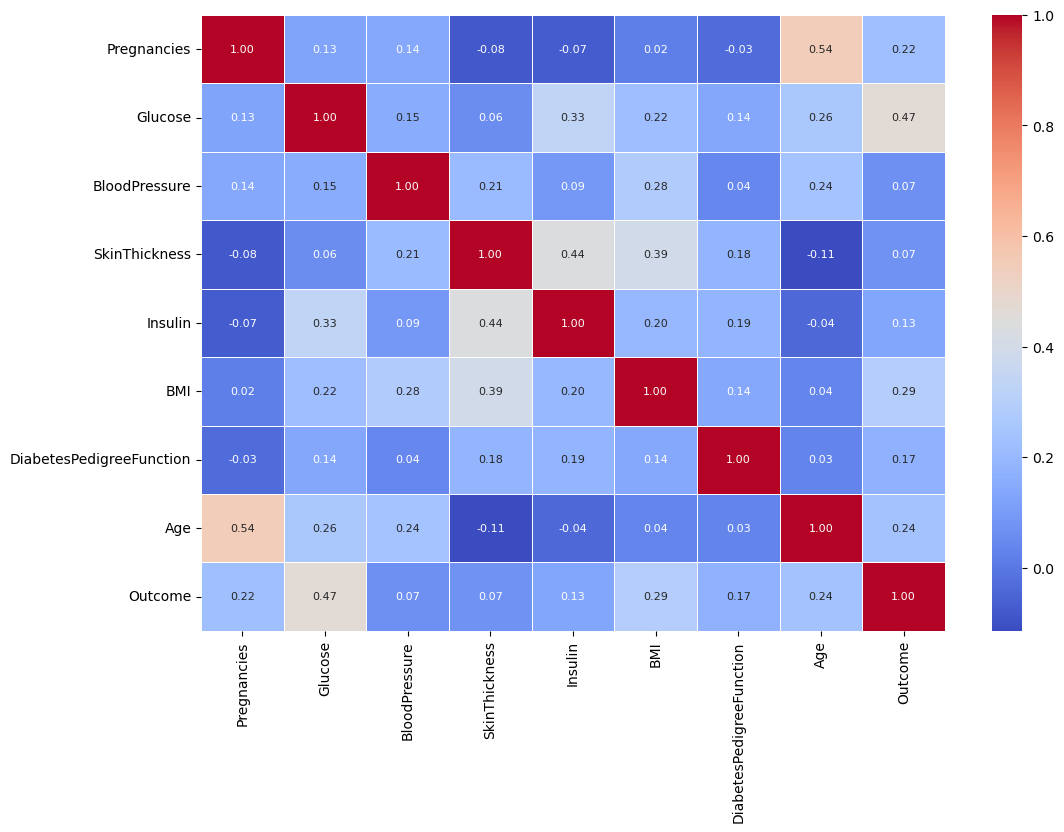

In [2]:
df = pd.read_csv("C:/Users/nooth/Downloads/archive (12)/diabetes.csv")
df.head()
print(df.shape)# Check dataset dimensions (rows, columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())#to check missing values
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()
plt.figure(figsize=(12, 8))
# Heatmap to visualize relationships between variables
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5, annot_kws={"size":8})

In [3]:
# These columns cannot be 0 in reality
zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Replace 0 with NaN so we can handle them properly
df[zero_not_valid] = df[zero_not_valid].replace(0, np.nan)
# Check how many actual missing values we now have
print(df.isnull().sum())
print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Percentage missing:
Pregnancies                  0.00
Glucose                      0.65
BloodPressure                4.56
SkinThickness               29.56
Insulin                     48.70
BMI                          1.43
DiabetesPedigreeFunction     0.00
Age                          0.00
Outcome                      0.00
dtype: float64


In [4]:
from sklearn.impute import SimpleImputer, KNNImputer

# Median imputation for low-missing columns
median_imputer = SimpleImputer(strategy='median')
df[['Glucose', 'BloodPressure', 'BMI']] = median_imputer.fit_transform(
    df[['Glucose', 'BloodPressure', 'BMI']]
)

# KNN imputation for high-missing columns
knn_imputer = KNNImputer(n_neighbors=5)
df[['SkinThickness', 'Insulin']] = knn_imputer.fit_transform(
    df[['SkinThickness', 'Insulin']]
)

# Confirm no missing values remain
print(df.isnull().sum())
print("\nShape:", df.shape)
print(df.describe().round(2))

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Shape: (768, 9)
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   121.66          72.39          29.15   153.37   32.46   
std           3.37    30.44          12.10           8.79    87.25    6.88   
min           0.00    44.00          24.00           7.00    14.00   18.20   
25%           1.00    99.75          64.00          25.00   103.60   27.50   
50%           3.00   117.00          72.00          29.15   155.55   32.30   
75%           6.00   140.25          80.00          32.00   160.00   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10  

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("\nTarget distribution (train):\n", y_train.value_counts(normalize=True))

Train shape: (614, 8)
Test shape: (154, 8)

Target distribution (train):
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


bash
   pip install tensorflow
   


2. **Using conda:**
   

bash
   conda install tensorflow
   


3. **If you're using Jupyter Notebook, you can install directly in a cell:**
   


Would you like me to provide the corrected code that includes the installation command?

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization

# Set seed for reproducibility
tf.random.set_seed(42)

# Build the ANN
model = keras.Sequential([
    # Input layer — 8 features going in
    layers.Dense(32, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    # Hidden layer 1
    layers.Dense(64, activation='relu'),
    BatchNormalization(),
    # Hidden layer 2
    layers.Dense(32, activation='relu'),
    BatchNormalization(),
    # Output layer — 1 neuron, sigmoid gives probability between 0 and 1
    layers.Dense(1, activation='sigmoid') 
])
# Compile — tell the model how to learn
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

The secret number N is: 58
Verification: 58 XOR 23 = 45


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,025 (19.63 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 256 (1.00 KB)

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

In [9]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

NameError: name 'early_stop' is not defined

In [42]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization





tf.random.set_seed(42)

model2 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    Dropout(0.2),  # randomly turns off 30% of neurons each batch → prevents memorization

    layers.Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    layers.Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    layers.Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Stop training automatically when val_loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,        # stop if no improvement for 10 consecutive epochs
    restore_best_weights=True  # revert to the best weights seen during training
)

history2 = model2.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Stopped at epoch:", len(history2.history['loss']))

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.4908 - loss: 0.9189 - val_accuracy: 0.6585 - val_loss: 0.6419
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6110 - loss: 0.7274 - val_accuracy: 0.7398 - val_loss: 0.6016
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6517 - loss: 0.6676 - val_accuracy: 0.7480 - val_loss: 0.5734
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6925 - loss: 0.5759 - val_accuracy: 0.7642 - val_loss: 0.5482
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7210 - loss: 0.5460 - val_accuracy: 0.7886 - val_loss: 0.5292
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6945 - loss: 0.5723 - val_accuracy: 0.7724 - val_loss: 0.5165
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7230 - loss: 0.5425 - val_accuracy: 0.7642 - val_loss: 0.5040
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7088 - loss: 0.5271 - val_accuracy: 0.

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
# Get predictions
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.4).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[63 37]
 [ 6 48]]
              precision    recall  f1-score   support

           0       0.91      0.63      0.75       100
           1       0.56      0.89      0.69        54

    accuracy                           0.72       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.72      0.73       154

ROC-AUC: 0.815


In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Get predictions
y_pred_proba = model2.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.4).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[79 21]
 [14 40]]
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       100
           1       0.66      0.74      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154

ROC-AUC: 0.830925925925926


In [45]:
model.summary()
model2.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,213 (16.46 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 128 (512.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,501 (41.02 KB)

 Trainable params: 3,425 (13.38 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 6,852 (26.77 KB)

In [46]:
print(max(history2.history['accuracy']))
print(max(history2.history['val_accuracy']))

0.8289205431938171
0.8048780560493469


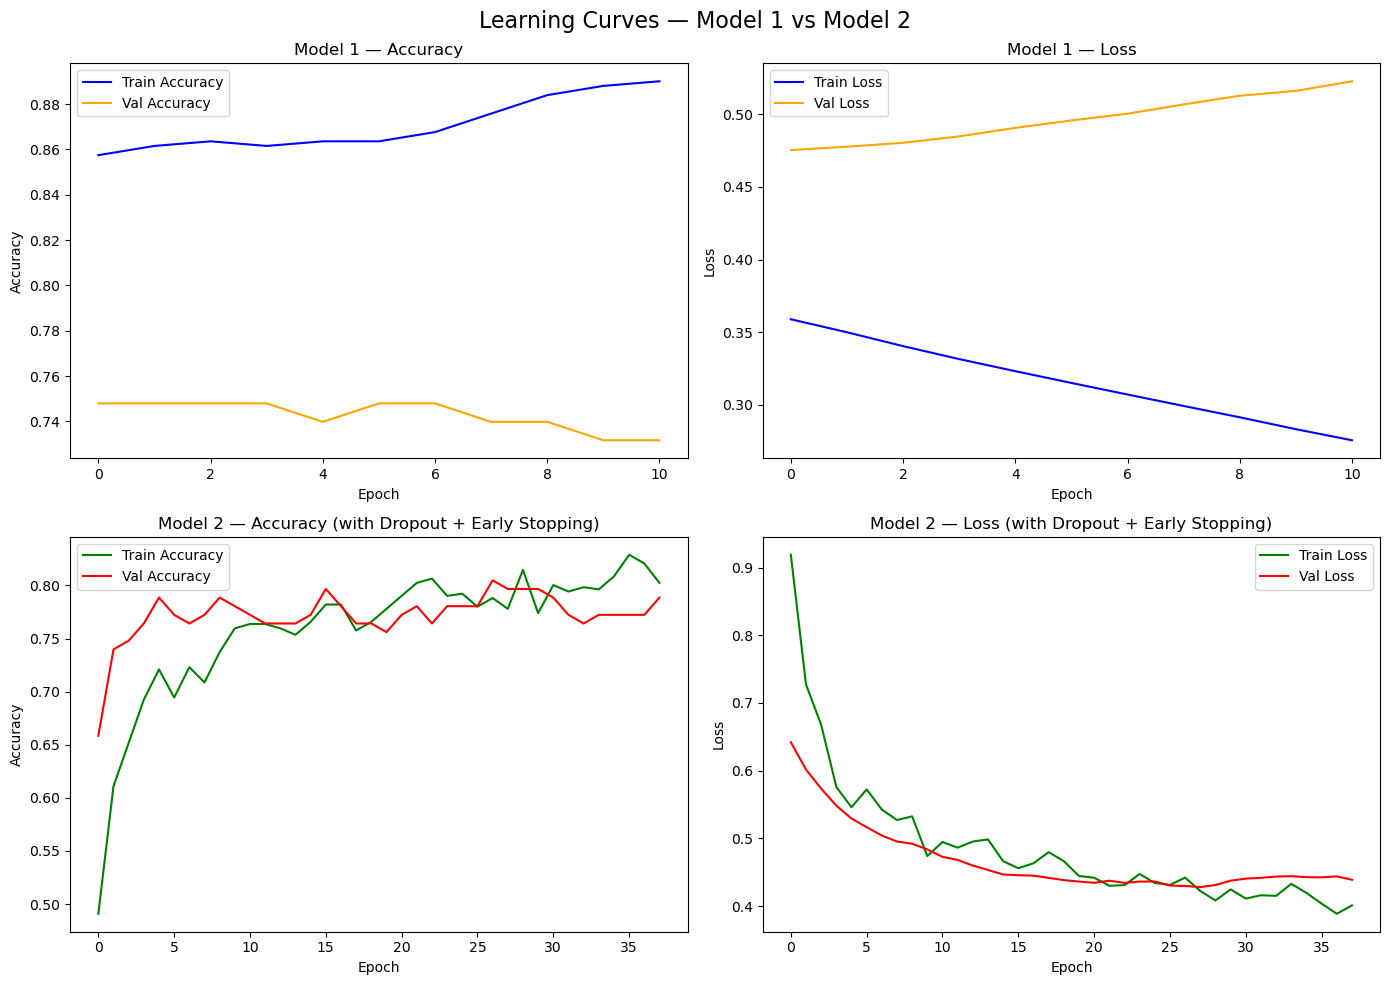

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learning Curves — Model 1 vs Model 2', fontsize=16)

# Model 1 - Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0, 0].set_title('Model 1 — Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Model 1 - Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0, 1].set_title('Model 1 — Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Model 2 - Accuracy
axes[1, 0].plot(history2.history['accuracy'], label='Train Accuracy', color='green')
axes[1, 0].plot(history2.history['val_accuracy'], label='Val Accuracy', color='red')
axes[1, 0].set_title('Model 2 — Accuracy (with Dropout + Early Stopping)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

# Model 2 - Loss
axes[1, 1].plot(history2.history['loss'], label='Train Loss', color='green')
axes[1, 1].plot(history2.history['val_loss'], label='Val Loss', color='red')
axes[1, 1].set_title('Model 2 — Loss (with Dropout + Early Stopping)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [51]:
import joblib
# Save the scaler — MUST save this, prediction time needs identical scaling
joblib.dump(scaler, 'scaler.pkl')
# Save the model in keras format
model2.save('diabetes_ann_model.keras')
print("Saved: diabetes_ann_model.keras, scaler.pkl")
# Quick sanity check — reload and test one prediction
from tensorflow.keras.models import load_model
loaded_model = load_model('diabetes_ann_model.keras')
test_input = X_test_scaled[0].reshape(1, -1)
print("Test prediction:", loaded_model.predict(test_input)[0][0])
print("Actual label:", y_test.iloc[0])

Saved: diabetes_ann_model.keras, scaler.pkl
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
Test prediction: 0.7669623
Actual label: 0
